# 03 — P-V cut examples

Per `plan.md` §11 step 3. Take 10 known B11 holes and 10 random
sightlines from the same galaxy and render their p-v cut windows.
Visual sanity: the catalogued holes should show the characteristic
ellipse / cavity signature; the random sightlines should not. If they
do, either the cube/catalog alignment from notebook 02 is off, or the
B11 catalog is mis-keyed.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from hishells.catalog import load_catalog
from hishells.cubes import load_cube, sigma_rms, world_to_pix, pix_to_world
from hishells.pvcut import extract_window_for_hole, extract_window

In [2]:
REPO = Path('..').resolve()
DATA = REPO / 'Data' / 'THINGS'
GALAXY = 'NGC_2403'  # change me

cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
cube = load_cube(DATA / f'{GALAXY}_NA_CUBE_THINGS.FITS')
sigma = sigma_rms(cube)
print(f'{GALAXY}: shape={cube.shape}, beam={cube.beam_bmaj_arcsec:.1f}", sigma_rms={sigma:.4g} Jy/beam')

NGC_2403: shape=(61, 2048, 2048), beam=8.8", sigma_rms=0.0003907 Jy/beam


In [3]:
# Pick 10 type-{2,3} holes (the ones we will train on per §2.4)
holes = cat.holes[(cat.holes['galaxy_id'] == GALAXY) & (cat.holes['hole_type'].isin([2, 3]))]
holes = holes.sort_values('diameter_pc', ascending=False).head(10).reset_index(drop=True)
print(f'showing {len(holes)} largest type-2/3 holes in {GALAXY}')

showing 10 largest type-2/3 holes in NGC_2403


In [4]:
def show_window(ax, win, title, sigma, vmin=None, vmax=None):
    if vmin is None or vmax is None:
        std = max(sigma, 1e-6)
        vmin, vmax = -2 * std, 8 * std
    ax.imshow(win, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

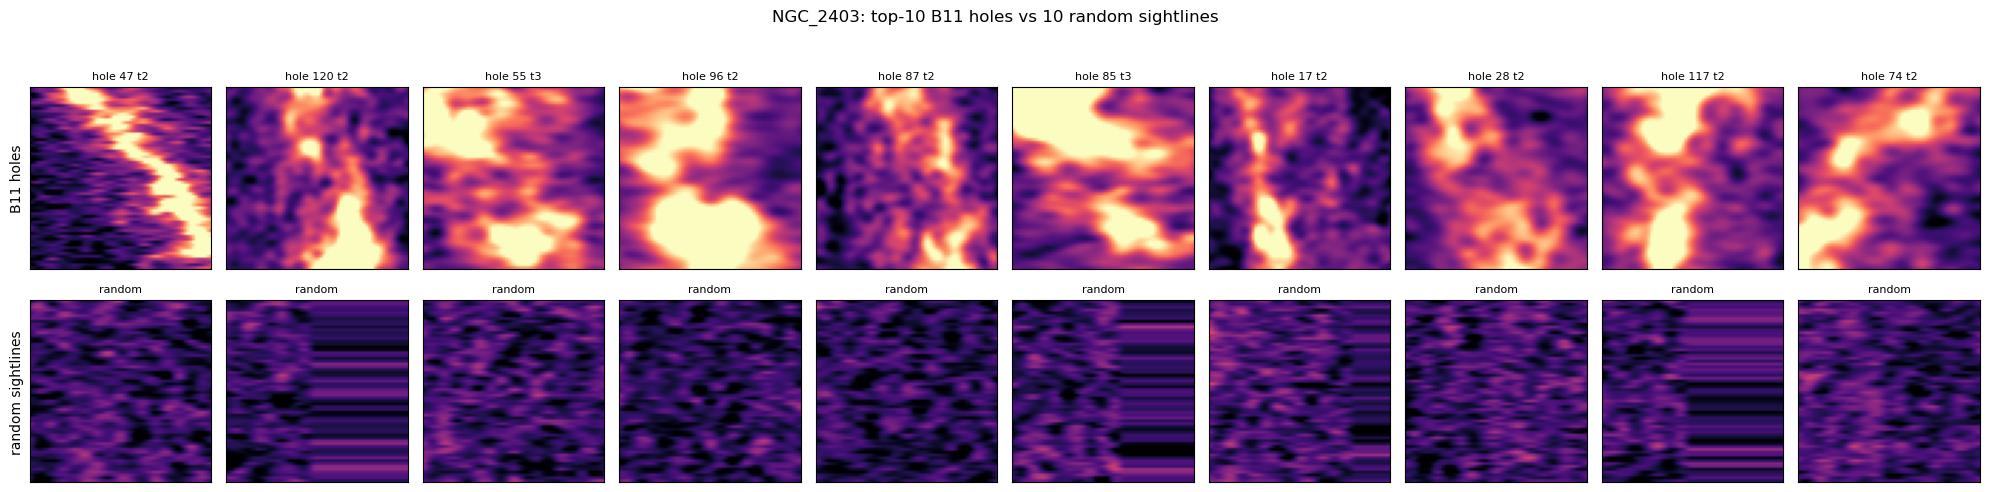

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for ax, (_, h) in zip(axes[0], holes.iterrows()):
    win = extract_window_for_hole(cube, h.to_dict(), window_pix=96)
    show_window(ax, win, f"hole {h.hole_idx} t{h.hole_type}", sigma)
axes[0, 0].set_ylabel('B11 holes', fontsize=10)

rng = np.random.default_rng(0)
for ax in axes[1]:
    ix = rng.integers(64, cube.shape[2] - 64)
    iy = rng.integers(64, cube.shape[1] - 64)
    iz = rng.integers(0, cube.n_chan - 1)
    ra, dec = pix_to_world(cube, np.array([ix]), np.array([iy]))
    win = extract_window(
        cube,
        ra_deg=float(ra[0]),
        dec_deg=float(dec[0]),
        vel_kms=float(cube.velocity_kms[iz]),
        pa_deg=float(rng.uniform(0, 180)),
        pos_extent_arcsec=80.0,
        vel_extent_kms=40.0,
    )
    show_window(ax, win, 'random', sigma)
axes[1, 0].set_ylabel('random sightlines', fontsize=10)
fig.suptitle(f'{GALAXY}: top-10 B11 holes vs 10 random sightlines', y=1.02)
plt.tight_layout()

## Pass criterion

* Top row: most windows show a low-flux interior with a brighter rim,
  often arranged into the expected p-v ellipse.
* Bottom row: random sightlines show either uniform emission, uniform
  noise (off-galaxy), or arbitrary structure -- but no consistent
  ellipse / cavity signature.

If random sightlines look indistinguishable from B11 holes, the
model has nothing to learn; revisit §2.1 / §2.2 before continuing.